# 🎵 Nepali Songs Language Classification

## Audio Classification using Deep Learning (TensorFlow/Keras)

This notebook implements a complete audio classification pipeline to classify songs into 5 different language categories:
- **Nepali** (नेपाली)
- **Bhojpuri** (भोजपुरी)
- **Maithili** (मैथिली)
- **Newari** (नेवारी)
- **Tamang** (तामाङ)

### Pipeline Overview:
1. **Data Exploration & Visualization** - Analyze audio samples with various visualizations
2. **Data Preprocessing** - Load, extract features (Mel Spectrograms), and balance classes
3. **Model Building** - Custom CNN architecture for audio classification
4. **Training** - Train with callbacks and class balancing
5. **Evaluation** - Confusion matrix, classification report, and visualizations

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

zip_path = "/content/drive/MyDrive/dataset.zip"
extract_path = "/content/data"

# Create the extraction directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Unzip the file
!unzip -q {zip_path} -d {extract_path}

print(f"Successfully extracted {zip_path} to {extract_path}")
print(f"Contents of {extract_path}:\n{os.listdir(extract_path)}")

Successfully extracted /content/drive/MyDrive/dataset.zip to /content/data
Contents of /content/data:
['dataset']


## 1. Import Required Libraries

In [4]:
# Core libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Audio processing
import librosa
import librosa.display

# Machine Learning / Deep Learning
import tensorflow as tf
from tensorflow import keras
from tf_keras import layers, models, callbacks
from tf_keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# For reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Check TensorFlow version and GPU availability
print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration and Dataset Path Setup

In [5]:
# Configuration
CONFIG = {
    # Dataset paths
    'dataset_path': r'/content/data/dataset',
    'model_save_path': r'/content/data/models',

    # Audio parameters
    'sample_rate': 22050,            # Standard sample rate for music
    'duration': 40,                  # Duration of each audio clip in seconds
    'n_mels': 128,                   # Number of mel bands
    'n_fft': 2048,                   # FFT window size
    'hop_length': 512,               # Hop length for STFT
    'max_time_steps': 1723,          # Max time steps (40s * 22050 / 512)

    # Training parameters
    'batch_size': 16,
    'epochs': 50,
    'learning_rate': 0.001,
    'validation_split': 0.2,
    'test_split': 0.1,
}

# Class names
CLASS_NAMES = ['bhojpuri', 'maithili', 'nepali', 'newari', 'tamang']
NUM_CLASSES = len(CLASS_NAMES)

# Create model directory if it doesn't exist
os.makedirs(CONFIG['model_save_path'], exist_ok=True)

print("Configuration loaded successfully!")
print(f"Dataset path: {CONFIG['dataset_path']}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Classes: {CLASS_NAMES}")

Configuration loaded successfully!
Dataset path: /content/data/dataset
Number of classes: 5
Classes: ['bhojpuri', 'maithili', 'nepali', 'newari', 'tamang']


## 3. Dataset Exploration and Class Distribution

In [6]:
# Explore the dataset
def explore_dataset(dataset_path):
    """Explore the dataset and return file information"""
    data_info = []

    for class_name in CLASS_NAMES:
        class_path = os.path.join(dataset_path, class_name)
        if os.path.exists(class_path):
            files = [f for f in os.listdir(class_path) if f.endswith('.mp3') or f.endswith('.wav')]
            for file in files:
                data_info.append({
                    'filename': file,
                    'class': class_name,
                    'filepath': os.path.join(class_path, file)
                })

    return pd.DataFrame(data_info)

# Get dataset info
df_dataset = explore_dataset(CONFIG['dataset_path'])
print(f"Total number of audio files: {len(df_dataset)}")
print("\n--- Class Distribution ---")
print(df_dataset['class'].value_counts())

Total number of audio files: 1347

--- Class Distribution ---
class
bhojpuri    284
maithili    270
newari      267
tamang      266
nepali      260
Name: count, dtype: int64


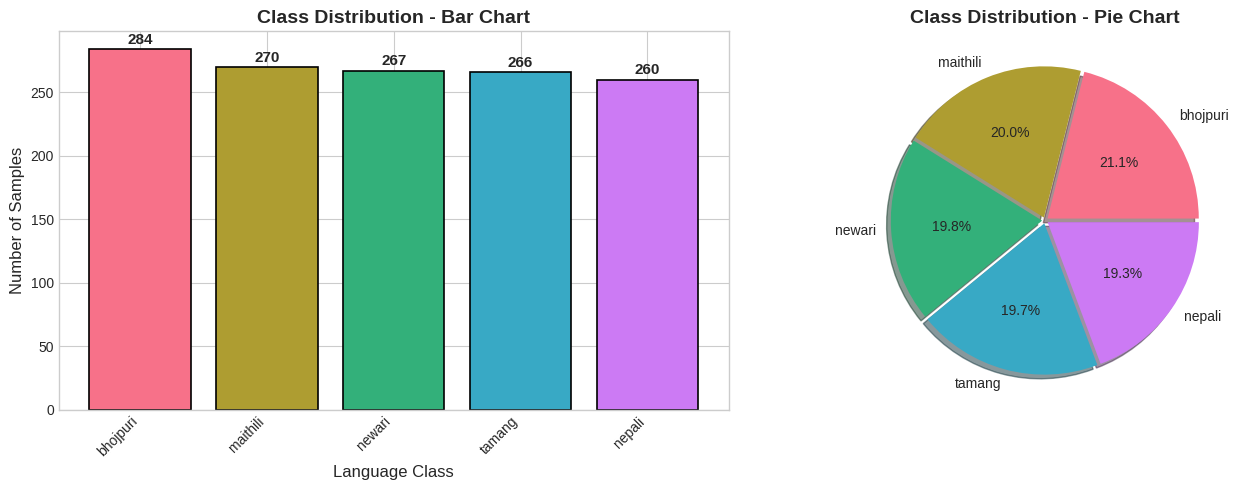


📊 Class Imbalance Analysis:
   Minimum samples: 260
   Maximum samples: 284
   Imbalance ratio: 1.09


In [7]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
class_counts = df_dataset['class'].value_counts()
colors = sns.color_palette("husl", n_colors=NUM_CLASSES)

ax1 = axes[0]
bars = ax1.bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', linewidth=1.2)
ax1.set_xlabel('Language Class', fontsize=12)
ax1.set_ylabel('Number of Samples', fontsize=12)
ax1.set_title('Class Distribution - Bar Chart', fontsize=14, fontweight='bold')
ax1.set_xticklabels(class_counts.index, rotation=45, ha='right')

# Add value labels on bars
for bar, count in zip(bars, class_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(class_counts.values, labels=class_counts.index,
                                    autopct='%1.1f%%', colors=colors,
                                    explode=[0.02]*NUM_CLASSES, shadow=True)
ax2.set_title('Class Distribution - Pie Chart', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['model_save_path'], 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

# Check for class imbalance
min_samples = class_counts.min()
max_samples = class_counts.max()
imbalance_ratio = max_samples / min_samples
print(f"\n📊 Class Imbalance Analysis:")
print(f"   Minimum samples: {min_samples}")
print(f"   Maximum samples: {max_samples}")
print(f"   Imbalance ratio: {imbalance_ratio:.2f}")

## 4. Audio Visualization (5 Different Visualizations)

Let's pick one sample from each class and visualize them using different audio visualization techniques:
1. **Waveform** - Time domain representation
2. **Mel Spectrogram** - Frequency representation with mel scale
3. **MFCC (Mel-Frequency Cepstral Coefficients)** - Feature representation
4. **Spectral Centroid** - Center of mass of the spectrum
5. **Chroma Features** - Pitch class representation

In [8]:
# Load a sample audio for visualization
def load_audio_sample(filepath, sr=22050, duration=40):
    """Load an audio file and return the waveform"""
    try:
        y, sr = librosa.load(filepath, sr=sr, duration=duration)
        return y, sr
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None, None

# Get one sample from each class for visualization
sample_audios = {}
for class_name in CLASS_NAMES:
    class_files = df_dataset[df_dataset['class'] == class_name]['filepath'].values
    if len(class_files) > 0:
        # Load the first file
        sample_path = class_files[0]
        y, sr = load_audio_sample(sample_path, CONFIG['sample_rate'], CONFIG['duration'])
        if y is not None:
            sample_audios[class_name] = {'audio': y, 'sr': sr, 'path': sample_path}
            print(f"✅ Loaded sample for {class_name}: {os.path.basename(sample_path)}")

print(f"\nLoaded {len(sample_audios)} audio samples for visualization")

✅ Loaded sample for bhojpuri: bhojpuri_154.mp3
✅ Loaded sample for maithili: maithili_227.mp3
✅ Loaded sample for nepali: nepali_1 (239).mp3
✅ Loaded sample for newari: newari_172.mp3
✅ Loaded sample for tamang: tamang_106.mp3

Loaded 5 audio samples for visualization


### 4.1 Waveform Visualization
The waveform shows the amplitude of the audio signal over time. It's the most basic representation of audio.

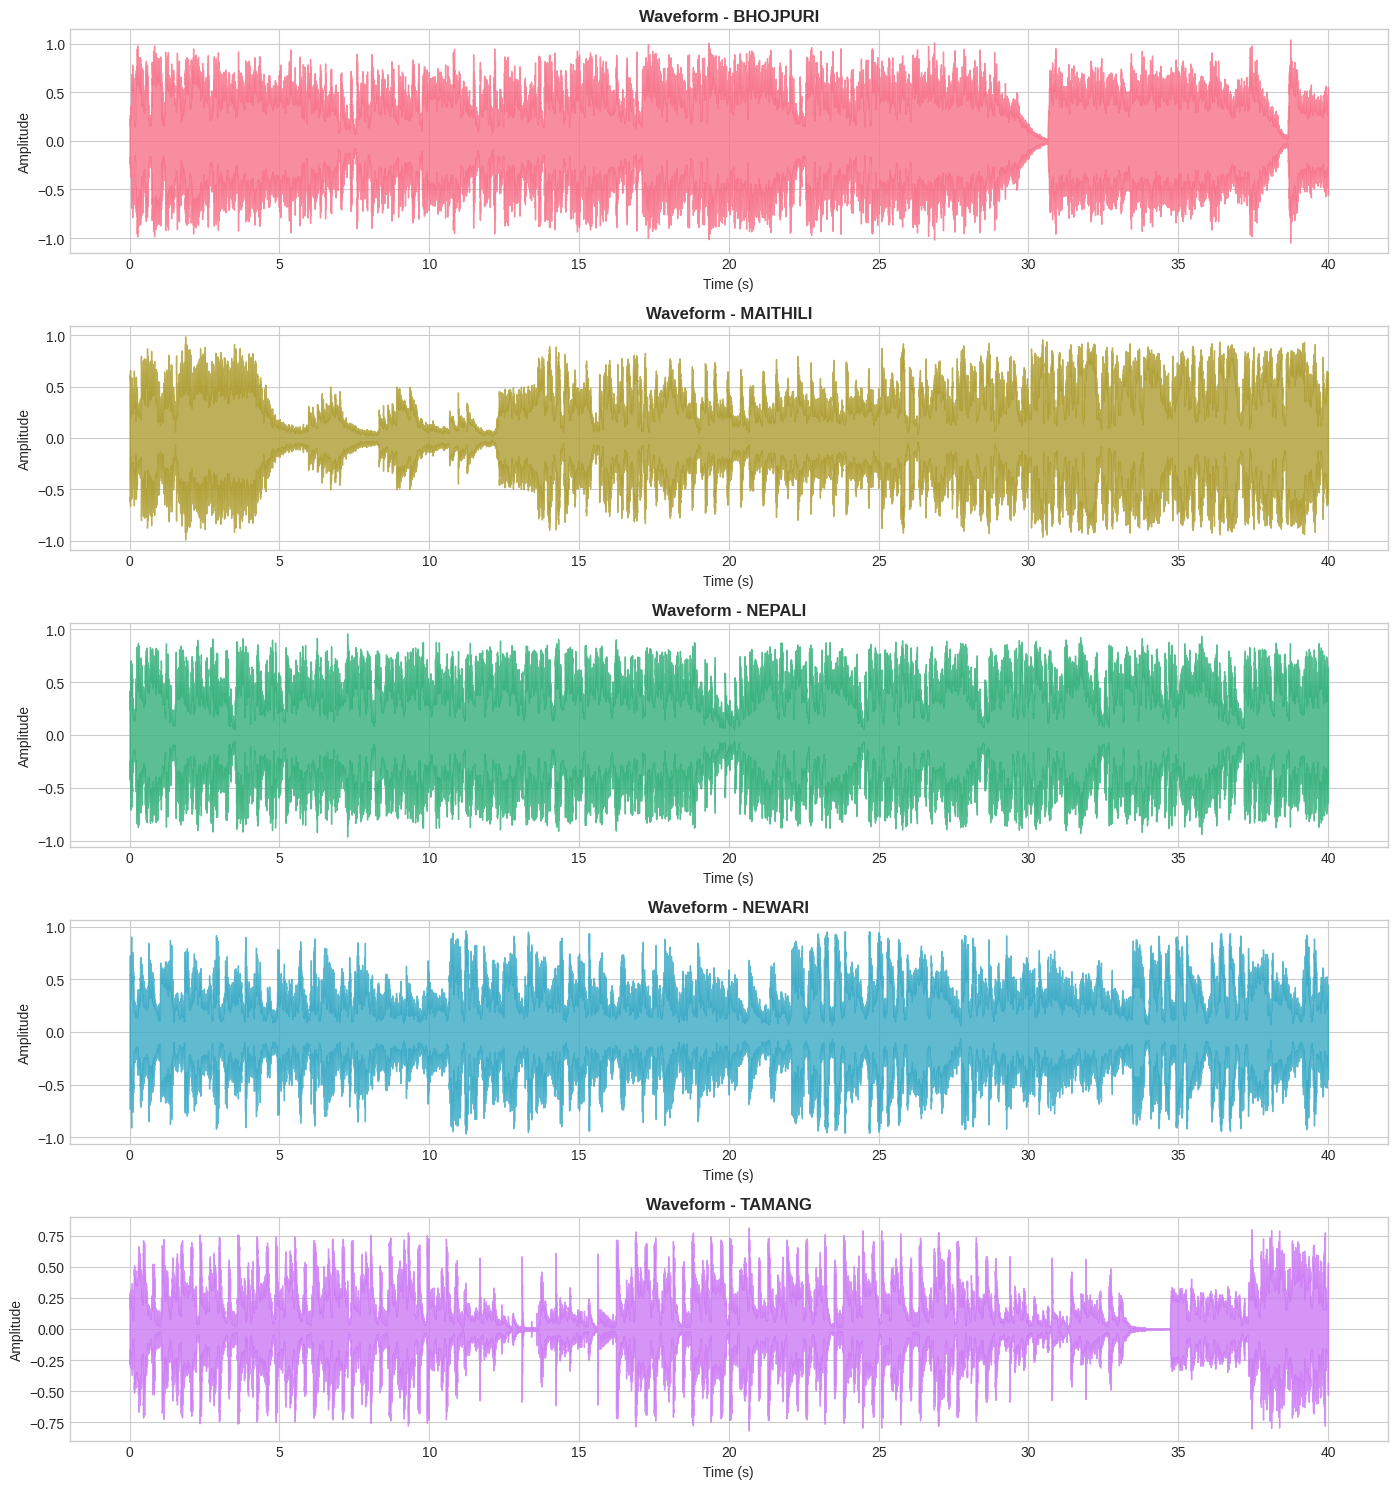

In [9]:
# Visualization 1: Waveform for all classes
fig, axes = plt.subplots(len(CLASS_NAMES), 1, figsize=(14, 3*len(CLASS_NAMES)))

colors = sns.color_palette("husl", n_colors=NUM_CLASSES)

for idx, (class_name, data) in enumerate(sample_audios.items()):
    y = data['audio']
    sr = data['sr']

    ax = axes[idx]
    librosa.display.waveshow(y, sr=sr, ax=ax, color=colors[idx], alpha=0.8)
    ax.set_title(f'Waveform - {class_name.upper()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['model_save_path'], 'waveforms.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Mel Spectrogram Visualization
Mel Spectrograms represent the frequency content of audio over time, using the mel scale which is closer to human perception.

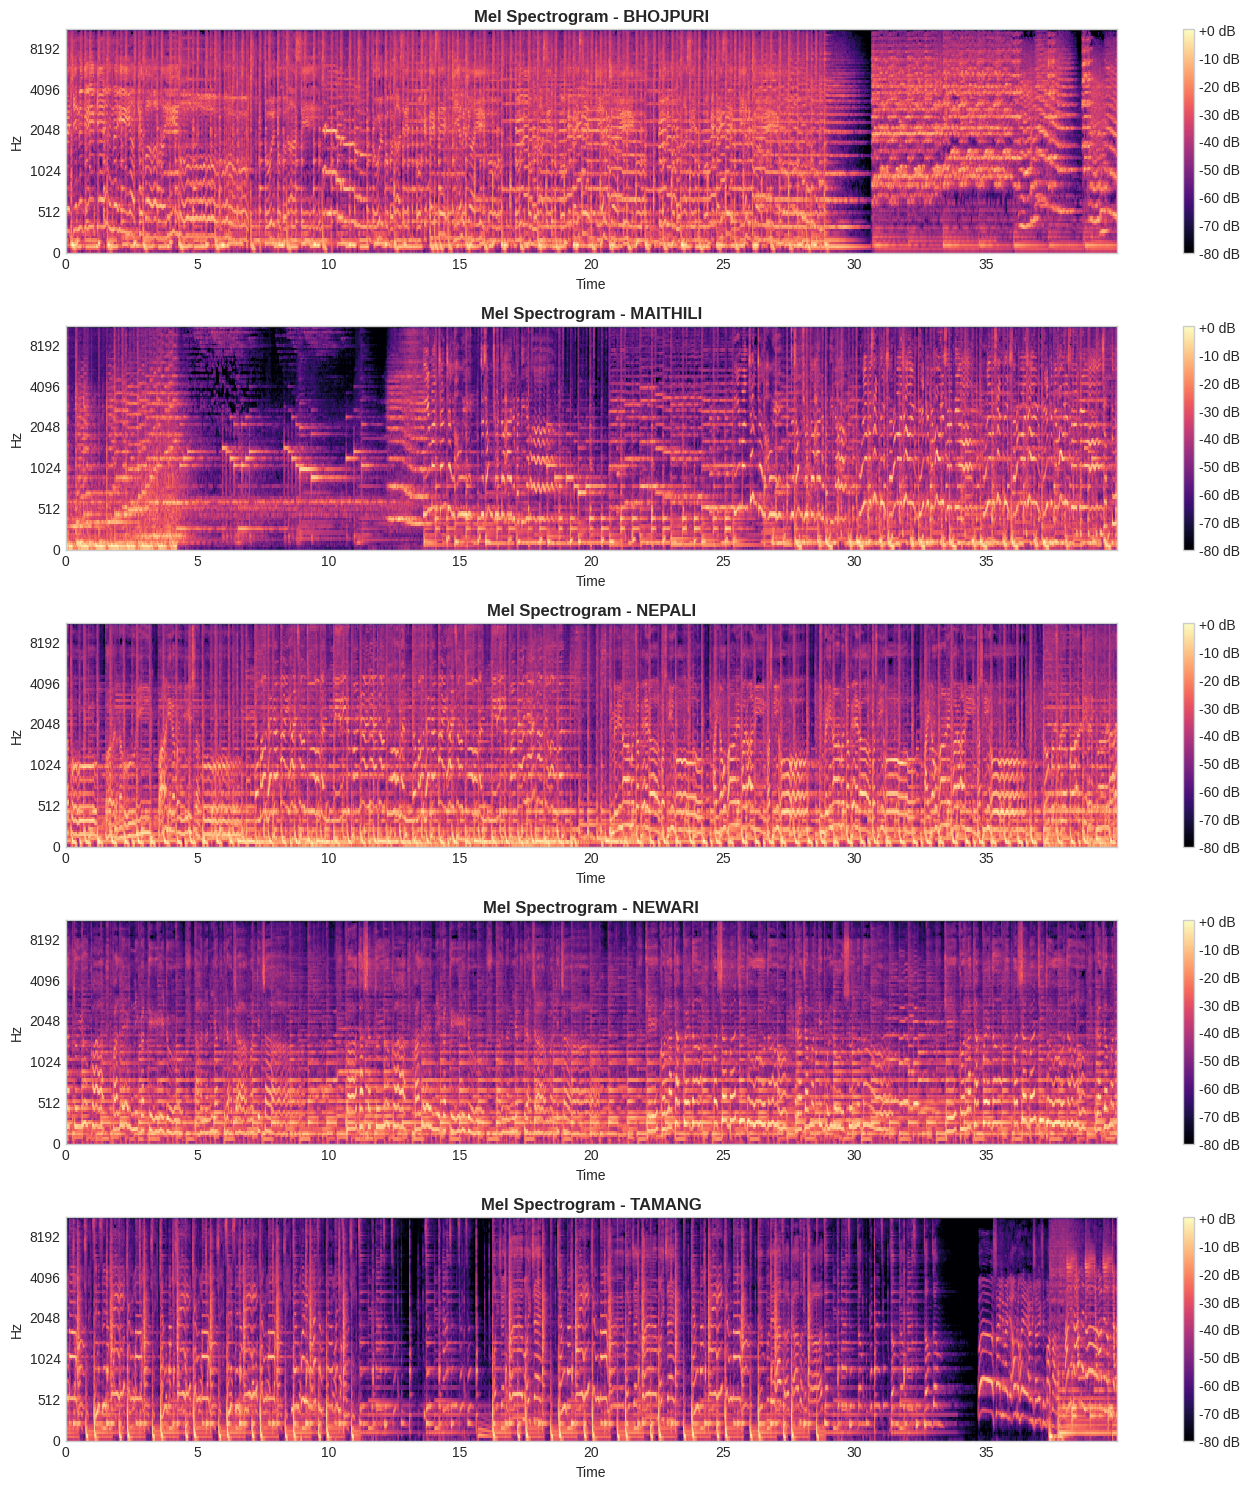

In [10]:
# Visualization 2: Mel Spectrogram for all classes
fig, axes = plt.subplots(len(CLASS_NAMES), 1, figsize=(14, 3*len(CLASS_NAMES)))

for idx, (class_name, data) in enumerate(sample_audios.items()):
    y = data['audio']
    sr = data['sr']

    # Compute mel spectrogram
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=CONFIG['n_mels'],
                                               n_fft=CONFIG['n_fft'], hop_length=CONFIG['hop_length'])
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    ax = axes[idx]
    img = librosa.display.specshow(mel_spec_db, sr=sr, hop_length=CONFIG['hop_length'],
                                    x_axis='time', y_axis='mel', ax=ax, cmap='magma')
    ax.set_title(f'Mel Spectrogram - {class_name.upper()}', fontsize=12, fontweight='bold')
    fig.colorbar(img, ax=ax, format='%+2.0f dB')

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['model_save_path'], 'mel_spectrograms.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4.3 MFCC (Mel-Frequency Cepstral Coefficients) Visualization
MFCCs capture the timbral characteristics of audio and are widely used in speech/music recognition.

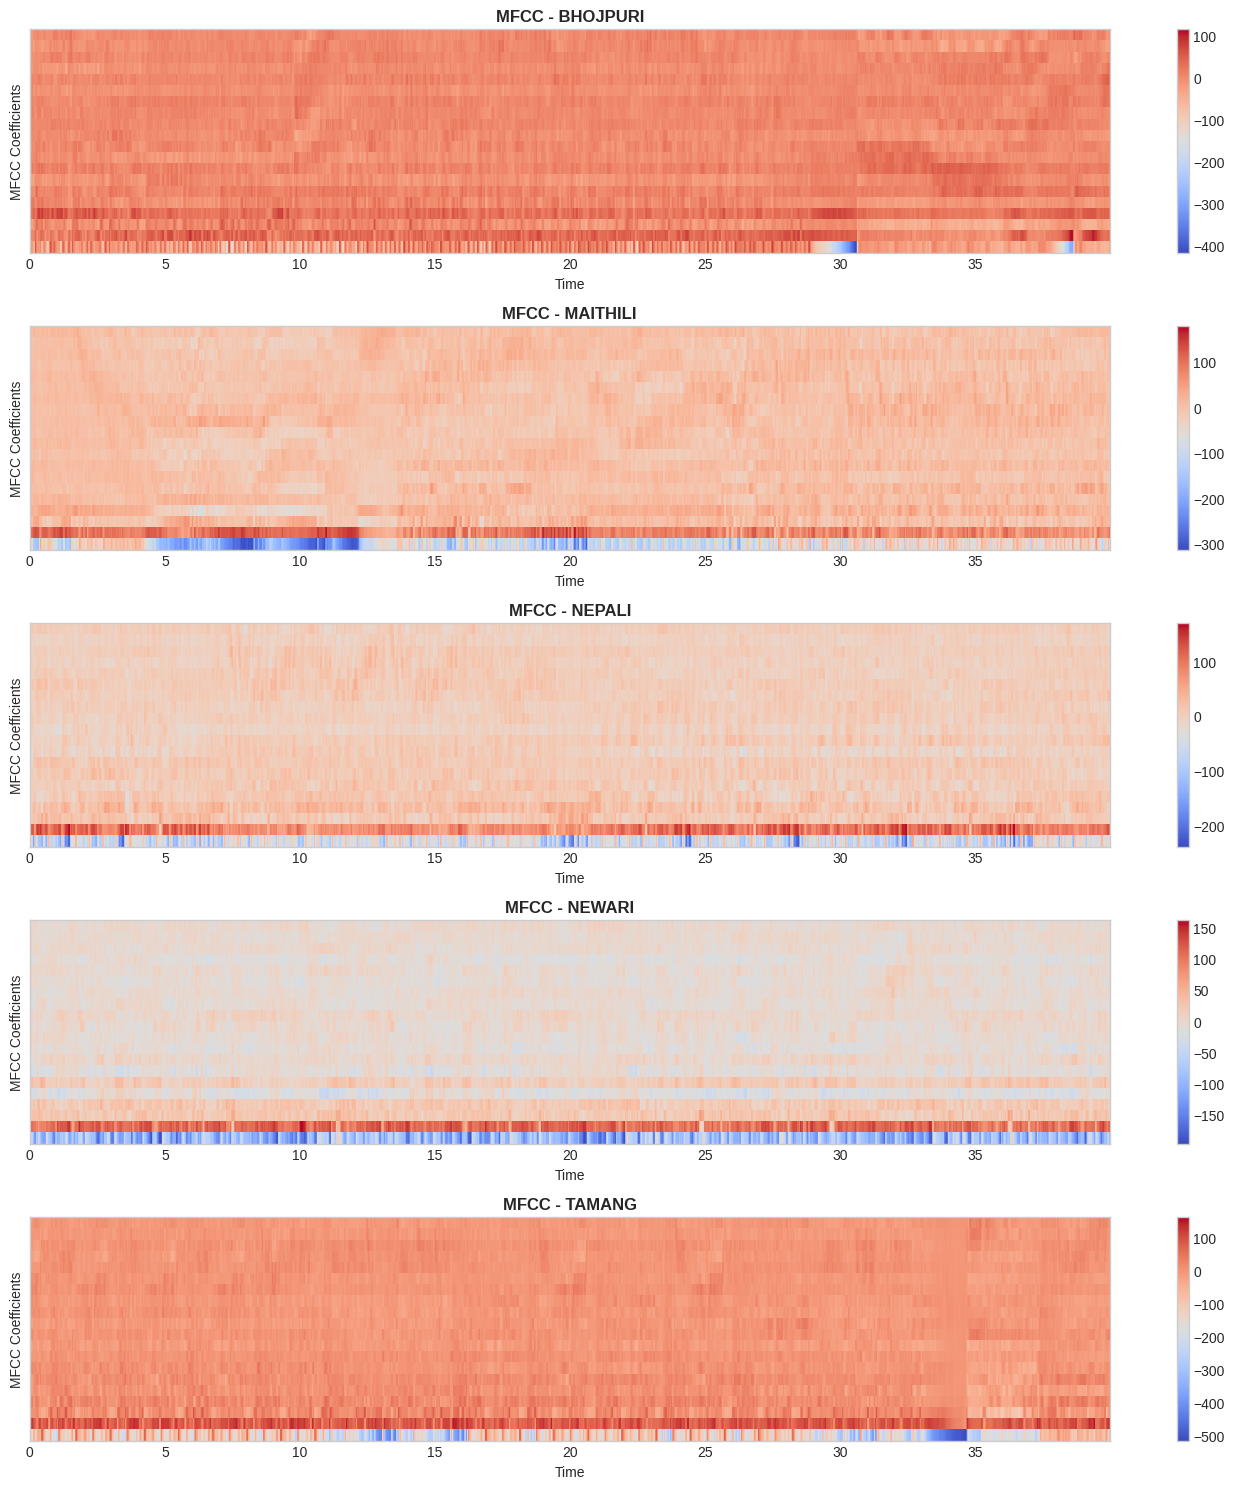

In [11]:
# Visualization 3: MFCC for all classes
fig, axes = plt.subplots(len(CLASS_NAMES), 1, figsize=(14, 3*len(CLASS_NAMES)))

for idx, (class_name, data) in enumerate(sample_audios.items()):
    y = data['audio']
    sr = data['sr']

    # Compute MFCCs
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20, n_fft=CONFIG['n_fft'],
                                  hop_length=CONFIG['hop_length'])

    ax = axes[idx]
    img = librosa.display.specshow(mfccs, sr=sr, hop_length=CONFIG['hop_length'],
                                    x_axis='time', ax=ax, cmap='coolwarm')
    ax.set_title(f'MFCC - {class_name.upper()}', fontsize=12, fontweight='bold')
    ax.set_ylabel('MFCC Coefficients')
    fig.colorbar(img, ax=ax)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['model_save_path'], 'mfccs.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Spectral Centroid and Rolloff Visualization
The spectral centroid indicates the "center of mass" of the spectrum - where the "brightness" of the sound is.

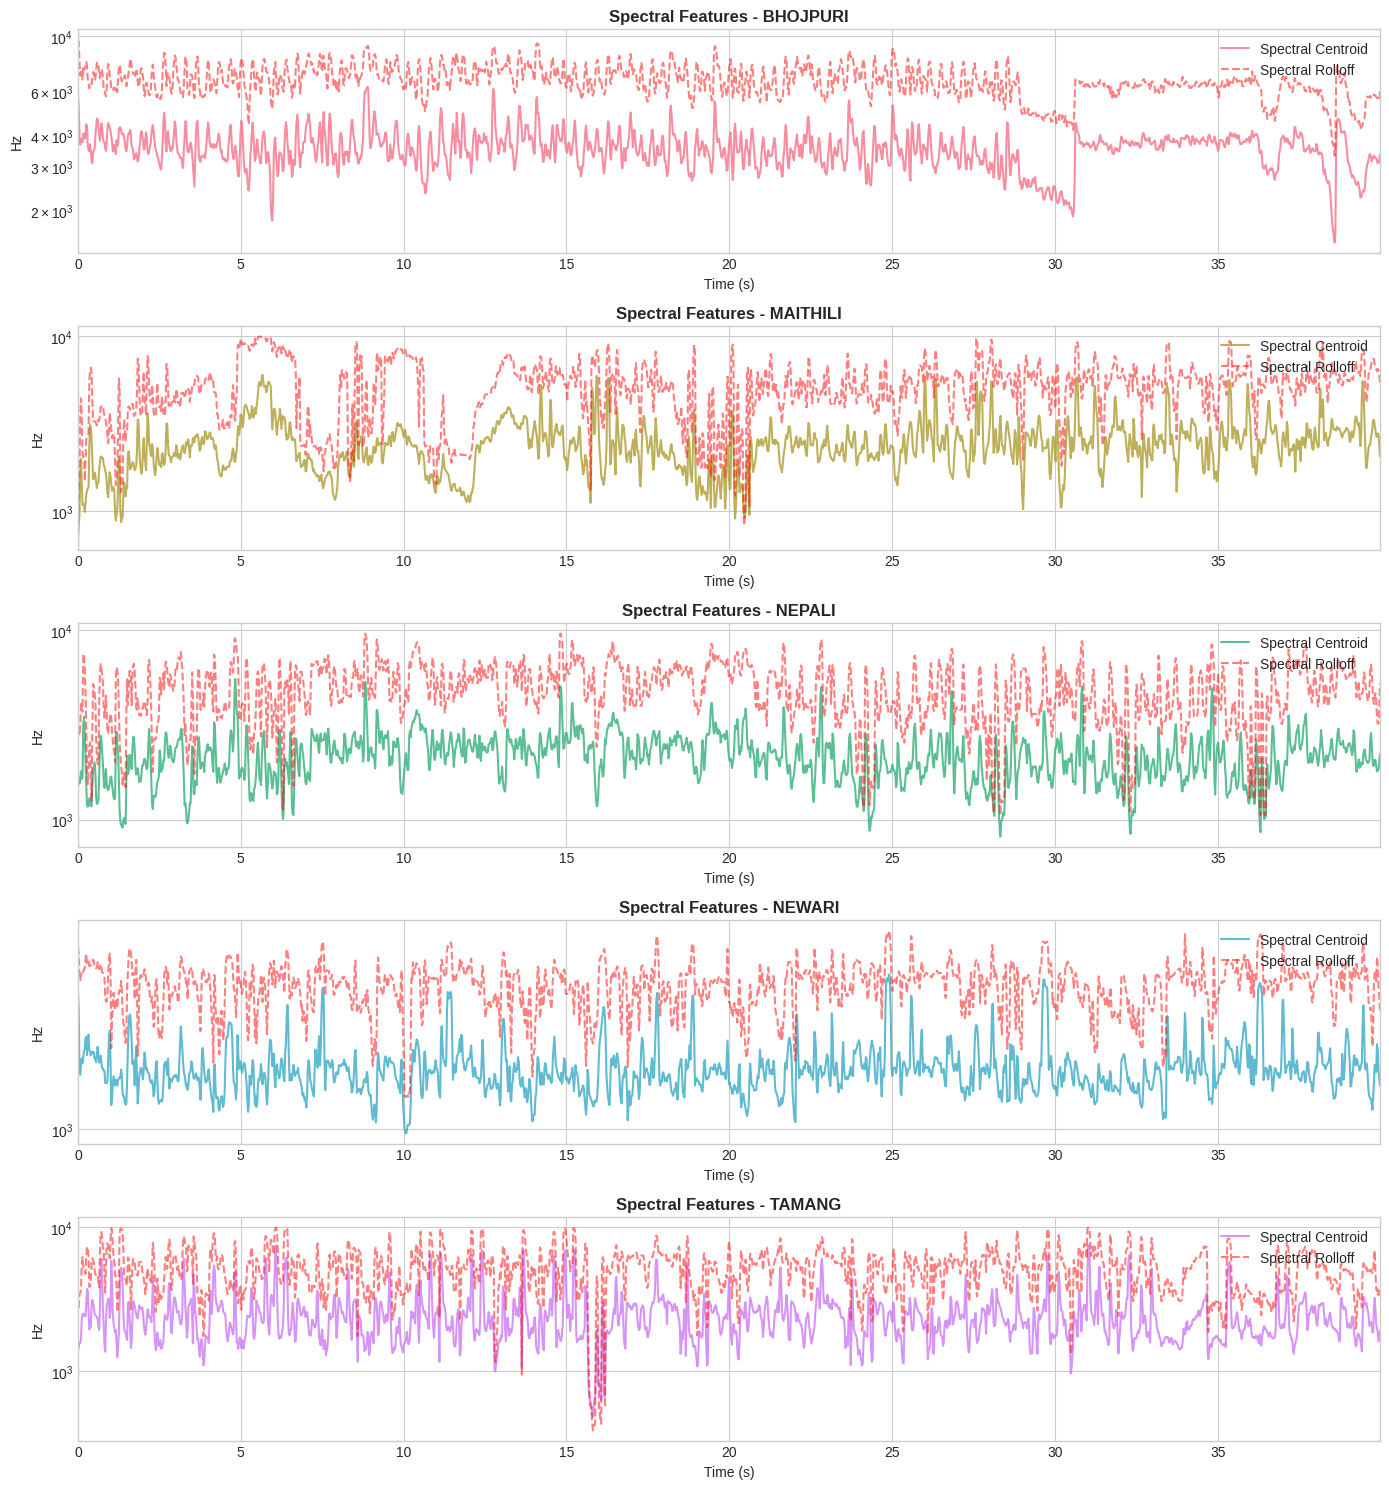

In [12]:
# Visualization 4: Spectral Centroid and Rolloff
fig, axes = plt.subplots(len(CLASS_NAMES), 1, figsize=(14, 3*len(CLASS_NAMES)))

colors = sns.color_palette("husl", n_colors=NUM_CLASSES)

for idx, (class_name, data) in enumerate(sample_audios.items()):
    y = data['audio']
    sr = data['sr']

    # Compute spectral features
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=CONFIG['hop_length'])[0]
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, hop_length=CONFIG['hop_length'])[0]

    # Time axis
    frames = range(len(spectral_centroid))
    t = librosa.frames_to_time(frames, sr=sr, hop_length=CONFIG['hop_length'])

    ax = axes[idx]

    # Normalize for visualization
    ax.semilogy(t, spectral_centroid, label='Spectral Centroid', color=colors[idx], alpha=0.8)
    ax.semilogy(t, spectral_rolloff, label='Spectral Rolloff', color='red', alpha=0.5, linestyle='--')

    ax.set_title(f'Spectral Features - {class_name.upper()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Hz')
    ax.legend(loc='upper right')
    ax.set_xlim([0, t[-1]])

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['model_save_path'], 'spectral_features.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4.5 Chroma Features Visualization
Chroma features represent the 12 different pitch classes (C, C#, D, ..., B) and are useful for understanding harmonic content.

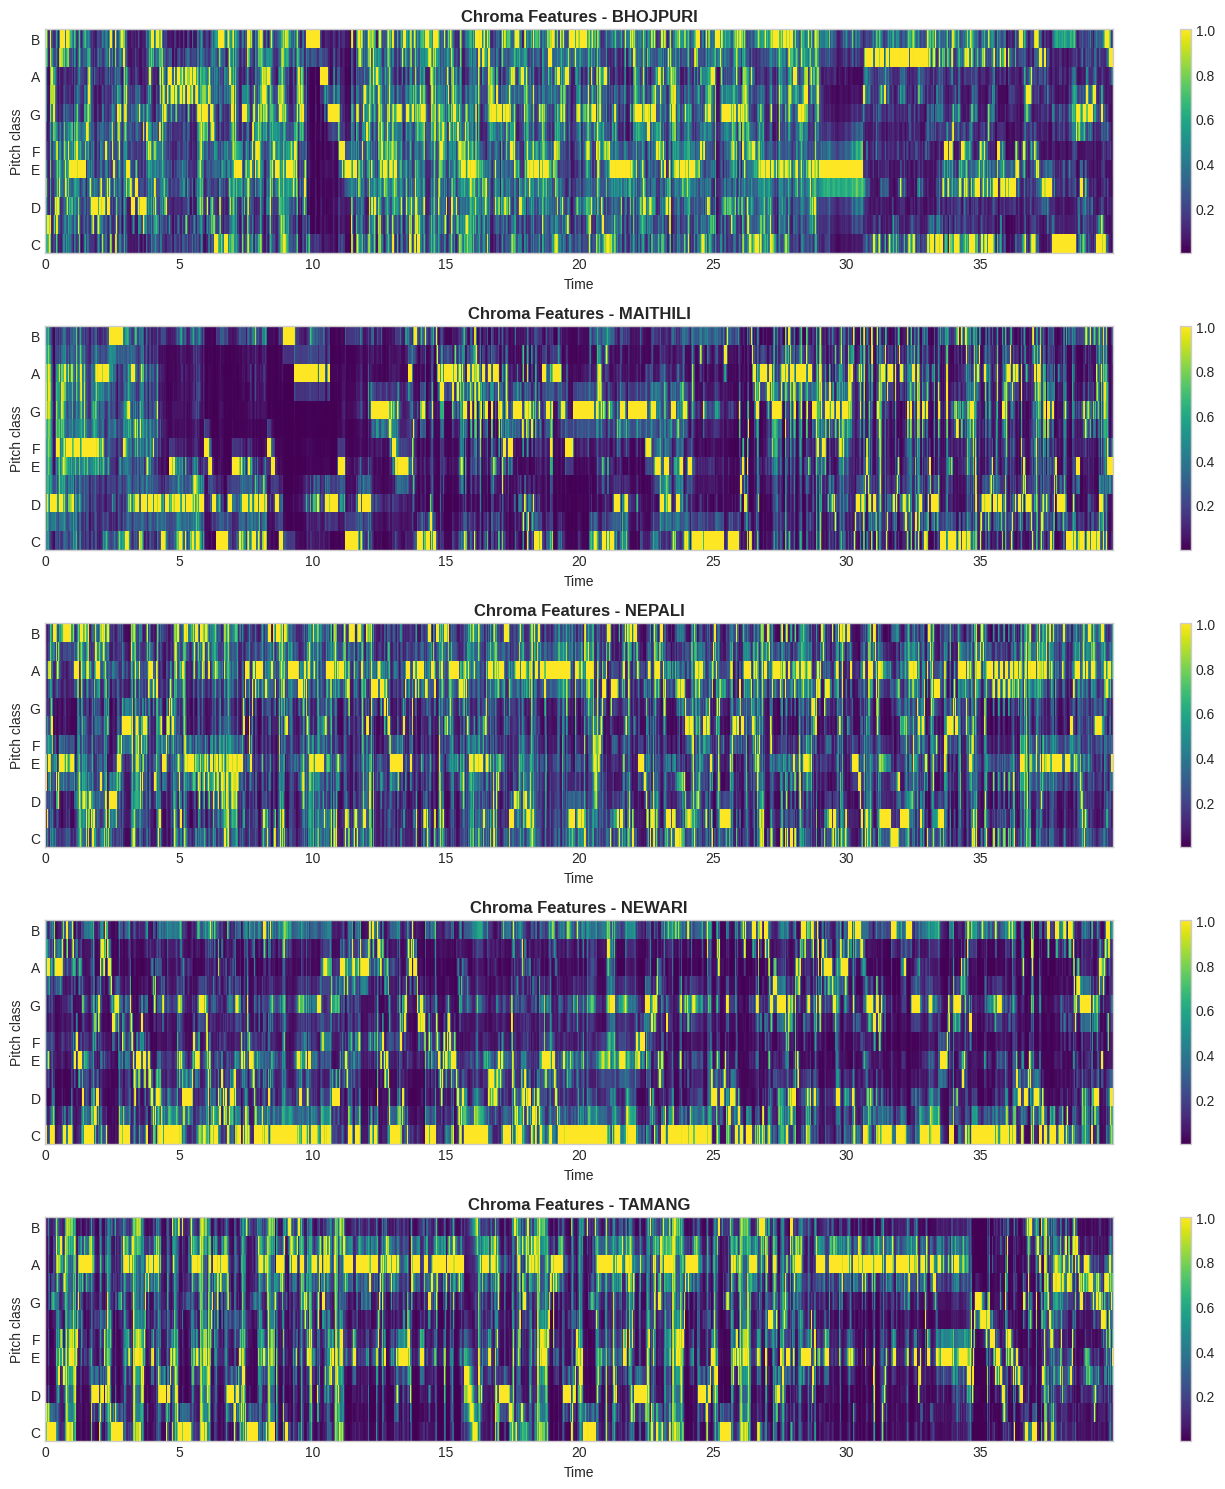

In [13]:
# Visualization 5: Chroma Features
fig, axes = plt.subplots(len(CLASS_NAMES), 1, figsize=(14, 3*len(CLASS_NAMES)))

for idx, (class_name, data) in enumerate(sample_audios.items()):
    y = data['audio']
    sr = data['sr']

    # Compute chroma features
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=CONFIG['n_fft'],
                                          hop_length=CONFIG['hop_length'])

    ax = axes[idx]
    img = librosa.display.specshow(chroma, sr=sr, hop_length=CONFIG['hop_length'],
                                    x_axis='time', y_axis='chroma', ax=ax, cmap='viridis')
    ax.set_title(f'Chroma Features - {class_name.upper()}', fontsize=12, fontweight='bold')
    fig.colorbar(img, ax=ax)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['model_save_path'], 'chroma_features.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4.6 Combined Audio Feature Comparison (Single Sample)
A comprehensive view of all audio features for one sample.

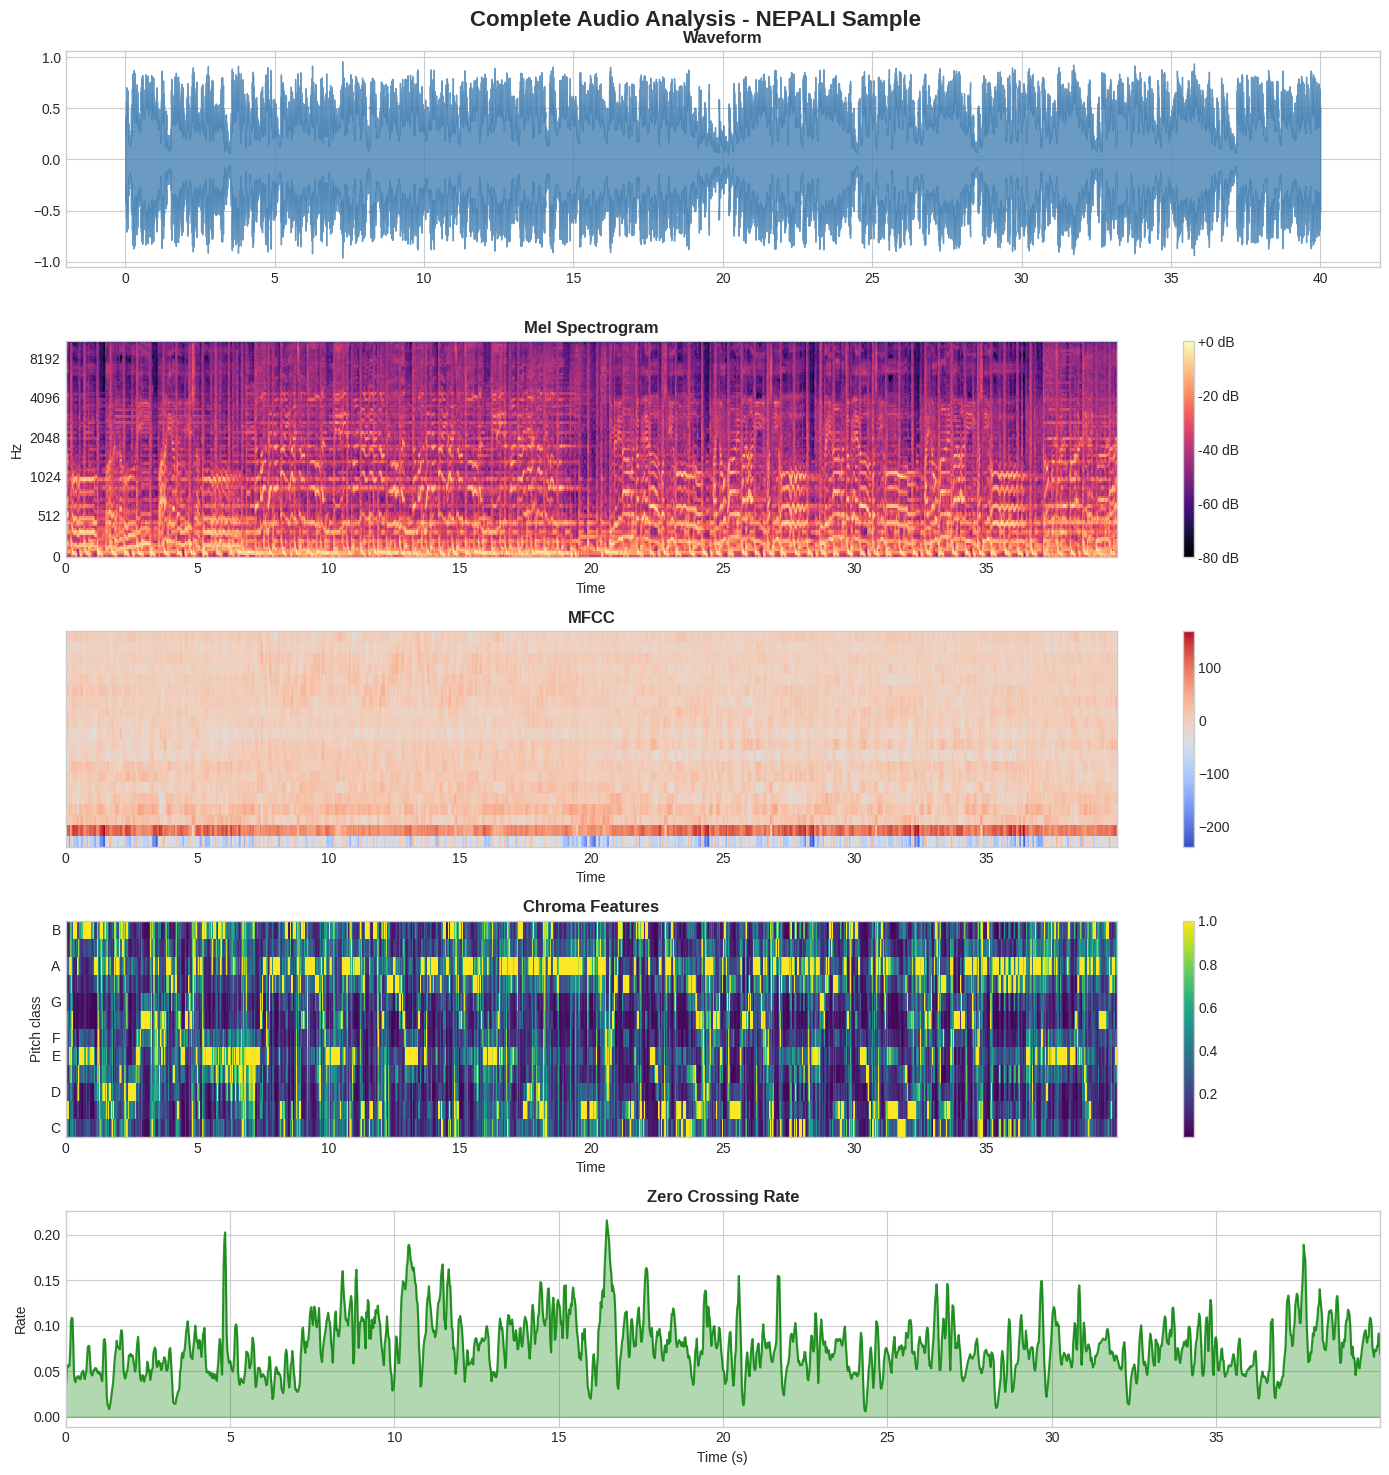

In [14]:
# Visualization 6: Combined features for one sample (Nepali)
sample_class = 'nepali'
y = sample_audios[sample_class]['audio']
sr = sample_audios[sample_class]['sr']

fig, axes = plt.subplots(5, 1, figsize=(14, 15))
fig.suptitle(f'Complete Audio Analysis - {sample_class.upper()} Sample', fontsize=16, fontweight='bold')

# 1. Waveform
ax1 = axes[0]
librosa.display.waveshow(y, sr=sr, ax=ax1, color='steelblue', alpha=0.8)
ax1.set_title('Waveform', fontsize=12, fontweight='bold')
ax1.set_xlabel('')

# 2. Mel Spectrogram
ax2 = axes[1]
mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=CONFIG['n_mels'],
                                           n_fft=CONFIG['n_fft'], hop_length=CONFIG['hop_length'])
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
img2 = librosa.display.specshow(mel_spec_db, sr=sr, hop_length=CONFIG['hop_length'],
                                 x_axis='time', y_axis='mel', ax=ax2, cmap='magma')
ax2.set_title('Mel Spectrogram', fontsize=12, fontweight='bold')
fig.colorbar(img2, ax=ax2, format='%+2.0f dB')

# 3. MFCC
ax3 = axes[2]
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20, n_fft=CONFIG['n_fft'],
                              hop_length=CONFIG['hop_length'])
img3 = librosa.display.specshow(mfccs, sr=sr, hop_length=CONFIG['hop_length'],
                                 x_axis='time', ax=ax3, cmap='coolwarm')
ax3.set_title('MFCC', fontsize=12, fontweight='bold')
fig.colorbar(img3, ax=ax3)

# 4. Chroma
ax4 = axes[3]
chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=CONFIG['n_fft'],
                                      hop_length=CONFIG['hop_length'])
img4 = librosa.display.specshow(chroma, sr=sr, hop_length=CONFIG['hop_length'],
                                 x_axis='time', y_axis='chroma', ax=ax4, cmap='viridis')
ax4.set_title('Chroma Features', fontsize=12, fontweight='bold')
fig.colorbar(img4, ax=ax4)

# 5. Zero Crossing Rate
ax5 = axes[4]
zcr = librosa.feature.zero_crossing_rate(y, hop_length=CONFIG['hop_length'])[0]
frames = range(len(zcr))
t = librosa.frames_to_time(frames, sr=sr, hop_length=CONFIG['hop_length'])
ax5.plot(t, zcr, color='green', alpha=0.8)
ax5.fill_between(t, zcr, alpha=0.3, color='green')
ax5.set_title('Zero Crossing Rate', fontsize=12, fontweight='bold')
ax5.set_xlabel('Time (s)')
ax5.set_ylabel('Rate')
ax5.set_xlim([0, t[-1]])

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['model_save_path'], 'combined_features.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Data Preprocessing and Feature Extraction

We'll extract Mel Spectrograms as features for our CNN model. This representation is ideal for audio classification tasks.

In [15]:
def extract_mel_spectrogram(file_path, sr=22050, duration=40, n_mels=128, n_fft=2048, hop_length=512):
    """
    Extract mel spectrogram from audio file.
    Returns a fixed-size mel spectrogram.
    """
    try:
        # Load audio file
        y, sr = librosa.load(file_path, sr=sr, duration=duration)

        # Pad or trim to ensure consistent length
        target_length = sr * duration
        if len(y) < target_length:
            y = np.pad(y, (0, target_length - len(y)), mode='constant')
        else:
            y = y[:target_length]

        # Extract mel spectrogram
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                                   n_fft=n_fft, hop_length=hop_length)

        # Convert to dB scale
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        return mel_spec_db

    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Test the function
test_file = df_dataset['filepath'].iloc[0]
test_spec = extract_mel_spectrogram(test_file, CONFIG['sample_rate'], CONFIG['duration'],
                                     CONFIG['n_mels'], CONFIG['n_fft'], CONFIG['hop_length'])
print(f"Mel Spectrogram shape: {test_spec.shape}")
print(f"Expected shape: ({CONFIG['n_mels']}, ~{CONFIG['max_time_steps']})")

Mel Spectrogram shape: (128, 1723)
Expected shape: (128, ~1723)


In [16]:
def load_and_preprocess_data(df, config, balance_classes=True):
    """
    Load all audio files and extract mel spectrograms.
    Optionally balance classes by undersampling.
    """
    features = []
    labels = []

    # Balance classes if needed
    if balance_classes:
        min_samples = df['class'].value_counts().min()
        print(f"Balancing classes to {min_samples} samples each...")
        balanced_df = df.groupby('class').apply(
            lambda x: x.sample(n=min_samples, random_state=42)
        ).reset_index(drop=True)
    else:
        balanced_df = df

    # Shuffle the dataframe
    balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

    print(f"Processing {len(balanced_df)} audio files...")

    for idx, row in balanced_df.iterrows():
        if idx % 50 == 0:
            print(f"  Processing: {idx}/{len(balanced_df)}")

        mel_spec = extract_mel_spectrogram(
            row['filepath'],
            sr=config['sample_rate'],
            duration=config['duration'],
            n_mels=config['n_mels'],
            n_fft=config['n_fft'],
            hop_length=config['hop_length']
        )

        if mel_spec is not None:
            features.append(mel_spec)
            labels.append(row['class'])

    # Convert to numpy arrays
    X = np.array(features)
    y = np.array(labels)

    print(f"\n✅ Loaded {len(X)} samples successfully!")
    print(f"   Feature shape: {X.shape}")
    print(f"   Labels shape: {y.shape}")

    return X, y

# Load and preprocess all data
X, y = load_and_preprocess_data(df_dataset, CONFIG, balance_classes=True)

Balancing classes to 260 samples each...
Processing 1300 audio files...
  Processing: 0/1300
  Processing: 50/1300
  Processing: 100/1300
  Processing: 150/1300
  Processing: 200/1300
  Processing: 250/1300
  Processing: 300/1300
  Processing: 350/1300
  Processing: 400/1300
  Processing: 450/1300
  Processing: 500/1300
  Processing: 550/1300
  Processing: 600/1300
  Processing: 650/1300
  Processing: 700/1300
  Processing: 750/1300
  Processing: 800/1300
  Processing: 850/1300
  Processing: 900/1300
  Processing: 950/1300
  Processing: 1000/1300
  Processing: 1050/1300
  Processing: 1100/1300
  Processing: 1150/1300
  Processing: 1200/1300
  Processing: 1250/1300

✅ Loaded 1300 samples successfully!
   Feature shape: (1300, 128, 1723)
   Labels shape: (1300,)


In [17]:
# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Label Encoding:")
for idx, class_name in enumerate(label_encoder.classes_):
    print(f"  {idx}: {class_name}")

# Add channel dimension for CNN (height, width, channels)
X = X[..., np.newaxis]
print(f"\nFinal feature shape: {X.shape}")

# One-hot encode labels
y_categorical = to_categorical(y_encoded, num_classes=NUM_CLASSES)
print(f"Labels shape: {y_categorical.shape}")

Label Encoding:
  0: bhojpuri
  1: maithili
  2: nepali
  3: newari
  4: tamang

Final feature shape: (1300, 128, 1723, 1)
Labels shape: (1300, 5)


In [18]:
# Split data into train, validation, and test sets
# First split: train+val vs test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y_categorical,
    test_size=CONFIG['test_split'],
    random_state=42,
    stratify=y_categorical
)

# Second split: train vs val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=CONFIG['validation_split']/(1-CONFIG['test_split']),
    random_state=42,
    stratify=y_train_val
)

print("Dataset Split:")
print(f"  Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Test set:       {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Normalize the data
X_train_mean = X_train.mean()
X_train_std = X_train.std()

X_train = (X_train - X_train_mean) / X_train_std
X_val = (X_val - X_train_mean) / X_train_std
X_test = (X_test - X_train_mean) / X_train_std

print(f"\nNormalization applied:")
print(f"  Mean: {X_train_mean:.4f}")
print(f"  Std:  {X_train_std:.4f}")

Dataset Split:
  Training set:   910 samples (70.0%)
  Validation set: 260 samples (20.0%)
  Test set:       130 samples (10.0%)

Normalization applied:
  Mean: -42.0319
  Std:  13.8489


## 6. Build Custom CNN Model for Audio Classification

We'll create a custom CNN architecture optimized for mel spectrogram classification.

In [19]:
import tf_keras

def build_audio_cnn(input_shape, num_classes):
    """
    Build a custom CNN model for audio classification.
    Architecture inspired by VGG-style networks adapted for spectrograms.
    """

    model = models.Sequential([
        # Input layer
        layers.Input(shape=input_shape),

        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=tf_keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=tf_keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=tf_keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=tf_keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=tf_keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=tf_keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 4
        layers.Conv2D(256, (3, 3), padding='same', kernel_regularizer=tf_keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(256, (3, 3), padding='same', kernel_regularizer=tf_keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Global Average Pooling
        layers.GlobalAveragePooling2D(),

        # Dense layers
        layers.Dense(512, kernel_regularizer=tf_keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),

        layers.Dense(256, kernel_regularizer=tf_keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),

        # Output layer
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Build model
input_shape = X_train.shape[1:]
print(f"Input shape: {input_shape}")

model = build_audio_cnn(input_shape, NUM_CLASSES)

# Compile model using tf_keras optimizer (consistent with model)
optimizer = tf_keras.optimizers.Adam(learning_rate=CONFIG['learning_rate'])
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

Input shape: (128, 1723, 1)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 1723, 32)     320       
                                                                 
 batch_normalization (Batch  (None, 128, 1723, 32)     128       
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 128, 1723, 32)     0         
                                                                 
 conv2d_1 (Conv2D)           (None, 128, 1723, 32)     9248      
                                                                 
 batch_normalization_1 (Bat  (None, 128, 1723, 32)     128       
 chNormalization)                                                
                                                                 
 activation_1 (Activation)  

In [20]:
# Visualize model architecture
from tf_keras.utils import plot_model

# Create a visual diagram of the model
try:
    plot_model(model, to_file=os.path.join(CONFIG['model_save_path'], 'model_architecture.png'),
               show_shapes=True, show_layer_names=True, dpi=100)
    print("Model architecture saved to 'model_architecture.png'")
except Exception as e:
    print(f"Could not save model diagram: {e}")
    print("This is optional - training will continue normally.")

Model architecture saved to 'model_architecture.png'


## 7. Training Setup with Callbacks and Class Weights

In [21]:
# Compute class weights to handle any remaining imbalance
y_train_labels = np.argmax(y_train, axis=1)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weight_dict = dict(enumerate(class_weights))

print("Class Weights:")
for idx, weight in class_weight_dict.items():
    print(f"  {label_encoder.classes_[idx]}: {weight:.4f}")

Class Weights:
  bhojpuri: 1.0000
  maithili: 1.0000
  nepali: 1.0000
  newari: 1.0000
  tamang: 1.0000


In [22]:
# Define callbacks
model_checkpoint = callbacks.ModelCheckpoint(
    filepath=os.path.join(CONFIG['model_save_path'], 'nepali_songs_classifier_best.keras'),
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# TensorBoard for visualization (optional)
tensorboard_callback = callbacks.TensorBoard(
    log_dir=os.path.join(CONFIG['model_save_path'], 'logs'),
    histogram_freq=1
)

callback_list = [model_checkpoint, early_stopping, reduce_lr]

print("✅ Callbacks configured:"
      "\n   - ModelCheckpoint (save best model)"
      "\n   - EarlyStopping (patience=10)"
      "\n   - ReduceLROnPlateau (factor=0.5, patience=5)")

✅ Callbacks configured:
   - ModelCheckpoint (save best model)
   - EarlyStopping (patience=10)
   - ReduceLROnPlateau (factor=0.5, patience=5)


## 8. Train the Model

In [23]:
# Train the model
print("🚀 Starting training...")
print(f"   Epochs: {CONFIG['epochs']}")
print(f"   Batch size: {CONFIG['batch_size']}")
print(f"   Training samples: {len(X_train)}")
print(f"   Validation samples: {len(X_val)}")
print("-" * 50)

history = model.fit(
    X_train, y_train,
    batch_size=CONFIG['batch_size'],
    epochs=CONFIG['epochs'],
    validation_data=(X_val, y_val),
    callbacks=callback_list,
    class_weight=class_weight_dict,
    verbose=1
)

print("\n✅ Training completed!")

🚀 Starting training...
   Epochs: 50
   Batch size: 16
   Training samples: 910
   Validation samples: 260
--------------------------------------------------
Epoch 1/50
57/57 [==============================] - ETA: 0s - loss: 3.0027 - accuracy: 0.4242
Epoch 1: val_accuracy improved from -inf to 0.32692, saving model to /content/data/models/nepali_songs_classifier_best.keras
57/57 [==============================] - 66s 822ms/step - loss: 3.0027 - accuracy: 0.4242 - val_loss: 3.5148 - val_accuracy: 0.3269 - lr: 0.0010
Epoch 2/50
57/57 [==============================] - ETA: 0s - loss: 2.6677 - accuracy: 0.5429
Epoch 2: val_accuracy improved from 0.32692 to 0.35769, saving model to /content/data/models/nepali_songs_classifier_best.keras
57/57 [==============================] - 38s 665ms/step - loss: 2.6677 - accuracy: 0.5429 - val_loss: 6.3240 - val_accuracy: 0.3577 - lr: 0.0010
Epoch 3/50
57/57 [==============================] - ETA: 0s - loss: 2.4162 - accuracy: 0.6363
Epoch 3: val_accu

## 9. Training History Visualization

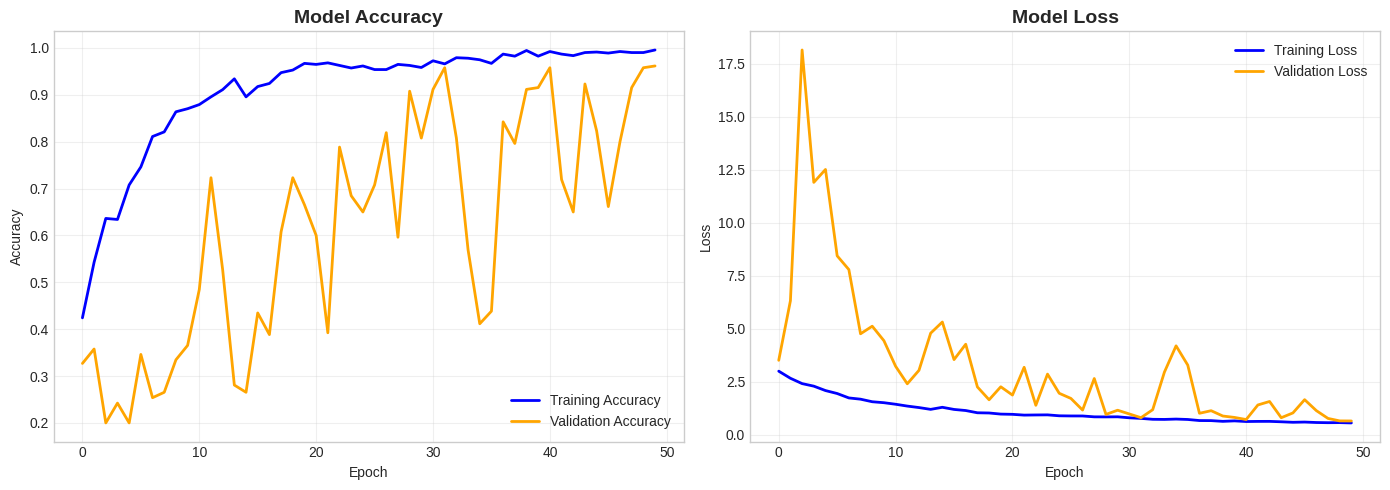

In [24]:
# Plot training history
def plot_training_history(history):
    """Plot training and validation metrics"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot accuracy
    ax1 = axes[0]
    ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, color='blue')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='orange')
    ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend(loc='lower right')
    ax1.grid(True, alpha=0.3)

    # Plot loss
    ax2 = axes[1]
    ax2.plot(history.history['loss'], label='Training Loss', linewidth=2, color='blue')
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='orange')
    ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['model_save_path'], 'training_history.png'), dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history(history)

## 10. Model Evaluation on Test Set

In [25]:
# Evaluate on test set
print("📊 Evaluating on test set...")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"\n{'='*50}")
print(f"Test Results:")
print(f"{'='*50}")
print(f"  Test Loss:     {test_loss:.4f}")
print(f"  Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"{'='*50}")

📊 Evaluating on test set...

Test Results:
  Test Loss:     0.6466
  Test Accuracy: 0.9462 (94.62%)


In [26]:
# Get predictions
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Classification report
print("\n📋 Classification Report:")
print("=" * 60)
print(classification_report(y_true_classes, y_pred_classes,
                           target_names=label_encoder.classes_))


📋 Classification Report:
              precision    recall  f1-score   support

    bhojpuri       0.89      0.96      0.93        26
    maithili       0.96      0.88      0.92        26
      nepali       1.00      0.88      0.94        26
      newari       0.90      1.00      0.95        26
      tamang       1.00      1.00      1.00        26

    accuracy                           0.95       130
   macro avg       0.95      0.95      0.95       130
weighted avg       0.95      0.95      0.95       130



## 11. Confusion Matrix Visualization

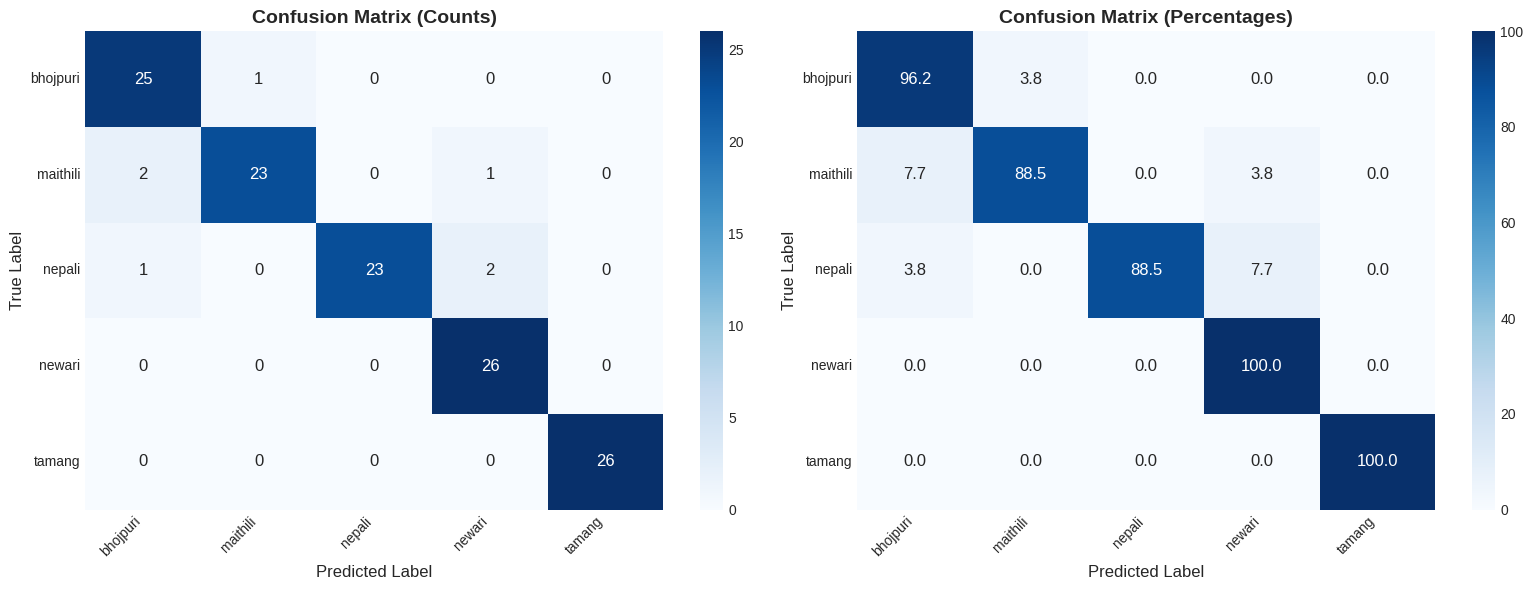

In [27]:
# Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    """Plot confusion matrix with percentages"""
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Raw counts
    ax1 = axes[0]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax1,
                annot_kws={"size": 12})
    ax1.set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Predicted Label', fontsize=12)
    ax1.set_ylabel('True Label', fontsize=12)
    ax1.set_xticklabels(class_names, rotation=45, ha='right')
    ax1.set_yticklabels(class_names, rotation=0)

    # Normalized (percentages)
    ax2 = axes[1]
    sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax2,
                annot_kws={"size": 12})
    ax2.set_title('Confusion Matrix (Percentages)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Predicted Label', fontsize=12)
    ax2.set_ylabel('True Label', fontsize=12)
    ax2.set_xticklabels(class_names, rotation=45, ha='right')
    ax2.set_yticklabels(class_names, rotation=0)

    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['model_save_path'], 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
    plt.show()

    return cm

cm = plot_confusion_matrix(y_true_classes, y_pred_classes, label_encoder.classes_)

## 12. Per-Class Accuracy Visualization

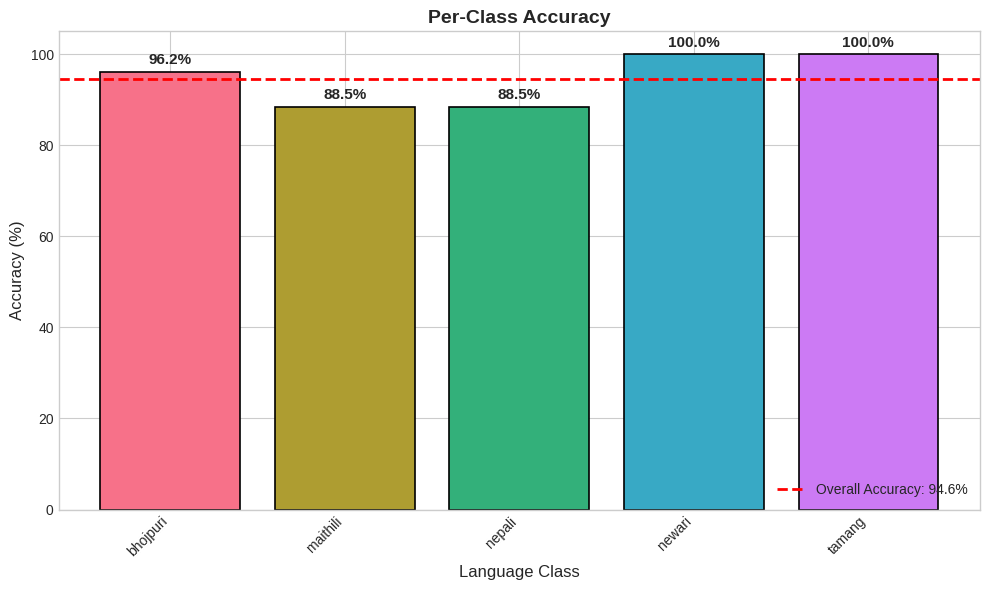

In [28]:
# Per-class accuracy
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("husl", n_colors=NUM_CLASSES)

bars = ax.bar(label_encoder.classes_, per_class_accuracy * 100, color=colors, edgecolor='black', linewidth=1.2)
ax.axhline(y=test_accuracy*100, color='red', linestyle='--', linewidth=2, label=f'Overall Accuracy: {test_accuracy*100:.1f}%')

ax.set_xlabel('Language Class', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Per-Class Accuracy', fontsize=14, fontweight='bold')
ax.set_ylim([0, 105])
ax.legend(loc='lower right')
ax.set_xticklabels(label_encoder.classes_, rotation=45, ha='right')

# Add value labels
for bar, acc in zip(bars, per_class_accuracy):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['model_save_path'], 'per_class_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()

## 13. Save the Final Model

In [29]:
# Save the final model
final_model_path = os.path.join(CONFIG['model_save_path'], 'nepali_songs_classifier_final.keras')
model.save(final_model_path)
print(f"✅ Final model saved to: {final_model_path}")

# Save the label encoder classes
import json
label_mapping = {int(i): label for i, label in enumerate(label_encoder.classes_)}
label_mapping_path = os.path.join(CONFIG['model_save_path'], 'label_mapping.json')
with open(label_mapping_path, 'w') as f:
    json.dump(label_mapping, f, indent=2)
print(f"✅ Label mapping saved to: {label_mapping_path}")

# Save normalization parameters
norm_params = {
    'mean': float(X_train_mean),
    'std': float(X_train_std)
}
norm_params_path = os.path.join(CONFIG['model_save_path'], 'normalization_params.json')
with open(norm_params_path, 'w') as f:
    json.dump(norm_params, f, indent=2)
print(f"✅ Normalization parameters saved to: {norm_params_path}")

✅ Final model saved to: /content/data/models/nepali_songs_classifier_final.keras
✅ Label mapping saved to: /content/data/models/label_mapping.json
✅ Normalization parameters saved to: /content/data/models/normalization_params.json


## 14. Prediction Function for New Audio Files

In [30]:
def predict_audio(audio_path, model, label_mapping, norm_mean, norm_std, config):
    """
    Predict the language class of a new audio file.

    Args:
        audio_path: Path to the audio file
        model: Trained Keras model
        label_mapping: Dictionary mapping class indices to labels
        norm_mean: Mean value for normalization
        norm_std: Standard deviation for normalization
        config: Configuration dictionary

    Returns:
        predicted_class: The predicted language class
        confidence: Confidence score for the prediction
        all_probabilities: Probabilities for all classes
    """
    # Extract mel spectrogram
    mel_spec = extract_mel_spectrogram(
        audio_path,
        sr=config['sample_rate'],
        duration=config['duration'],
        n_mels=config['n_mels'],
        n_fft=config['n_fft'],
        hop_length=config['hop_length']
    )

    if mel_spec is None:
        return None, None, None

    # Add batch and channel dimensions
    mel_spec = mel_spec[np.newaxis, ..., np.newaxis]

    # Normalize
    mel_spec = (mel_spec - norm_mean) / norm_std

    # Predict
    predictions = model.predict(mel_spec, verbose=0)
    predicted_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_idx]
    predicted_class = label_mapping[predicted_idx]

    # Get all probabilities
    all_probs = {label_mapping[i]: float(predictions[0][i]) for i in range(len(predictions[0]))}

    return predicted_class, confidence, all_probs

# Example usage
print("📝 Prediction function created!")
print("\nUsage:")
print("  predicted_class, confidence, all_probs = predict_audio(")
print("      'path/to/audio.mp3', model, label_mapping, X_train_mean, X_train_std, CONFIG")
print("  )")

📝 Prediction function created!

Usage:
  predicted_class, confidence, all_probs = predict_audio(
      'path/to/audio.mp3', model, label_mapping, X_train_mean, X_train_std, CONFIG
  )


## 15. Summary and Next Steps

In [32]:
# Summary
print("=" * 60)
print("🎉 TRAINING COMPLETE - SUMMARY")
print("=" * 60)
print(f"\n📊 Dataset:")
print(f"   Total samples used: {len(X)}")
print(f"   Classes: {', '.join(CLASS_NAMES)}")
print(f"   Audio duration: {CONFIG['duration']} seconds")

print(f"\n🏗️ Model Architecture:")
print(f"   Type: Custom CNN (VGG-style)")
print(f"   Input shape: {input_shape}")
print(f"   Total parameters: {model.count_params():,}")

print(f"\n📈 Training Configuration:")
print(f"   Epochs trained: {len(history.history['loss'])}")
print(f"   Batch size: {CONFIG['batch_size']}")
print(f"   Learning rate: {CONFIG['learning_rate']}")

print(f"\n✅ Final Results:")
print(f"   Test Accuracy: {test_accuracy*100:.2f}%")
print(f"   Test Loss: {test_loss:.4f}")

print(f"\n💾 Saved Files:")
print(f"   1. Model: nepali_songs_classifier_final.keras")
print(f"   2. Best Model: nepali_songs_classifier_best.keras")
print(f"   3. Label Mapping: label_mapping.json")
print(f"   4. Normalization Params: normalization_params.json")
print(f"   5. Visualizations: class_distribution.png, training_history.png, confusion_matrix.png, etc.")

print(f"\n🚀 Next Steps:")
print("   1. Use the predict_audio() function for new predictions")
print("   2. Fine-tune hyperparameters for better accuracy")
print("   3. Try data augmentation (pitch shift, time stretch)")
print("   4. Experiment with transfer learning (VGGish, YAMNet)")
print("=" * 60)

🎉 TRAINING COMPLETE - SUMMARY

📊 Dataset:
   Total samples used: 1300
   Classes: bhojpuri, maithili, nepali, newari, tamang
   Audio duration: 40 seconds

🏗️ Model Architecture:
   Type: Custom CNN (VGG-style)
   Input shape: (128, 1723, 1)
   Total parameters: 1,442,789

📈 Training Configuration:
   Epochs trained: 50
   Batch size: 16
   Learning rate: 0.001

✅ Final Results:
   Test Accuracy: 94.62%
   Test Loss: 0.6466

💾 Saved Files:
   1. Model: nepali_songs_classifier_final.keras
   2. Best Model: nepali_songs_classifier_best.keras
   3. Label Mapping: label_mapping.json
   4. Normalization Params: normalization_params.json
   5. Visualizations: class_distribution.png, training_history.png, confusion_matrix.png, etc.

🚀 Next Steps:
   1. Use the predict_audio() function for new predictions
   2. Fine-tune hyperparameters for better accuracy
   3. Try data augmentation (pitch shift, time stretch)
   4. Experiment with transfer learning (VGGish, YAMNet)
